# **Loading the dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("marusagar/bank-transaction-fraud-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-transaction-fraud-detection' dataset.
Path to dataset files: /kaggle/input/bank-transaction-fraud-detection


In [3]:
import os
print(os.listdir(path))

['Bank_Transaction_Fraud_Detection.csv']


In [4]:
import pandas as pd

# Update the filename to match the exact capitalization:
csv_file_path = f"{path}/Bank_Transaction_Fraud_Detection.csv"

# Load the dataset
df = pd.read_csv(csv_file_path)
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


# **Setup**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# **Dataset overview**

In [6]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [7]:
print("shape",df.shape)
print("Size",df.size)

shape (200000, 24)
Size 4800000


In [8]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='object')

In [9]:
df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


**Target imbalance**

In [10]:
df['Is_Fraud'].value_counts(normalize=True)*100

,proportion
Is_Fraud,
0,94.956
1,5.044


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

**Duplicate Records**

In [12]:
df.duplicated().sum()

np.int64(0)

# **Univariate analysis**

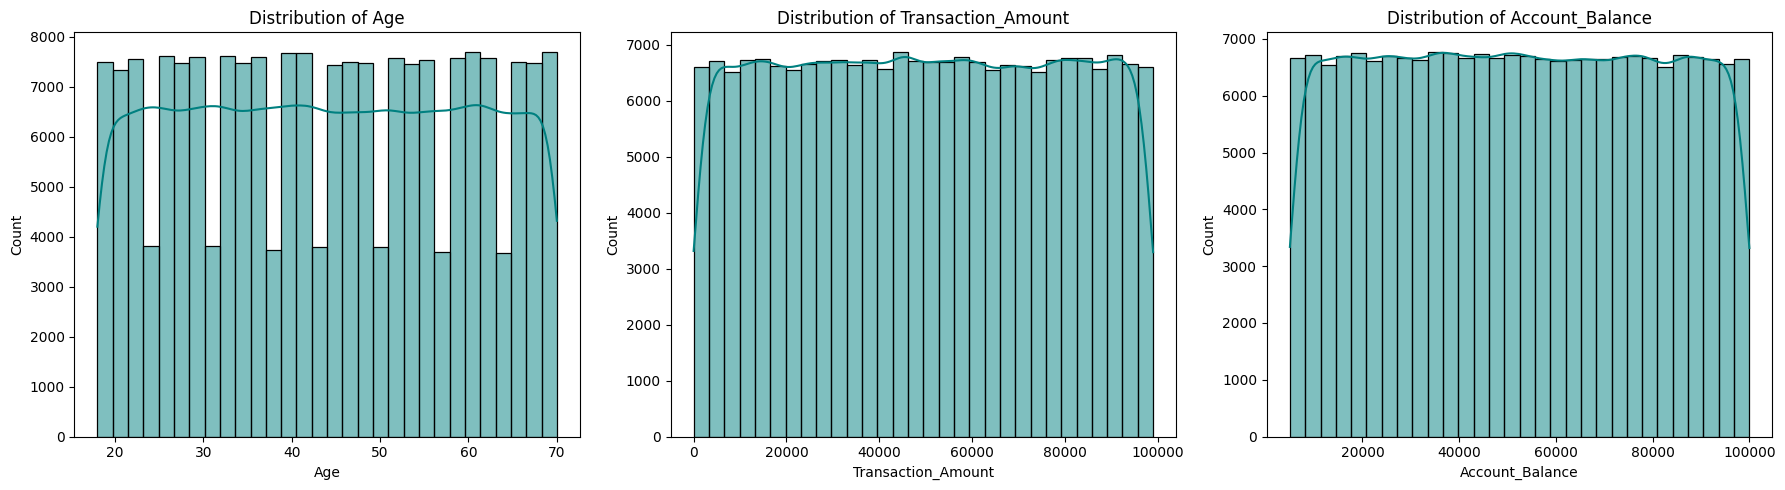

In [13]:
numeric_cols = ['Age', 'Transaction_Amount', 'Account_Balance']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i], bins=30, kde=True, color='teal')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [19]:
df[['Customer_ID','Customer_Name','Transaction_Description','Transaction_Location']]
#High cardinality and very low predictive power

,Customer_ID,Customer_Name,Transaction_Description,Transaction_Location
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Bitcoin transaction,"Thiruvananthapuram, Kerala"
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Grocery delivery,"Nashik, Maharashtra"
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Mutual fund investment,"Bhagalpur, Bihar"
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Food delivery,"Chennai, Tamil Nadu"
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Debt repayment,"Amritsar, Punjab"
...,...,...,...,...
199995,b8bdae19-296f-48b7-9104-e055d33a09ac,Vedhika Magar,ATM withdrawal,"Diu, Dadra and Nagar Haveli and Daman and Diu"
199996,635bc099-8a93-48ee-829a-bf2283fe8fda,Aashi Pai,Subscription box,"Kangpokpi, Manipur"
199997,c1b31cc2-0905-47e8-8cc5-6461d1f3ba33,Dayita Shan,Charity donation,"Chandigarh, Chandigarh"
199998,32bb8e66-f3fa-43bf-8242-dab9a6116310,Unnati Vyas,Tourist attraction payment,"Nizamabad, Telangana"


In [20]:
df[['Bank_Branch','Transaction_Currency']]

,Bank_Branch,Transaction_Currency
0,Thiruvananthapuram Branch,INR
1,Nashik Branch,INR
2,Bhagalpur Branch,INR
3,Chennai Branch,INR
4,Amritsar Branch,INR
...,...,...
199995,Diu Branch,INR
199996,Kangpokpi Branch,INR
199997,Chandigarh Branch,INR
199998,Nizamabad Branch,INR


In [22]:
df['Transaction_Currency'].nunique()

1

In [24]:
df['Transaction_Description'].nunique()

172

In [29]:
df['Gender'].value_counts()

,count
Gender,
Male,100452
Female,99548


In [31]:
print(df['State'].unique())
print(df['State'].nunique())

['Kerala' 'Maharashtra' 'Bihar' 'Tamil Nadu' 'Punjab' 'Gujarat' 'Delhi'
 'Andaman and Nicobar Islands' 'Madhya Pradesh' 'Chhattisgarh' 'Mizoram'
 'West Bengal' 'Sikkim' 'Dadra and Nagar Haveli and Daman and Diu'
 'Uttar Pradesh' 'Odisha' 'Tripura' 'Assam' 'Manipur' 'Karnataka'
 'Andhra Pradesh' 'Goa' 'Haryana' 'Lakshadweep' 'Jharkhand' 'Meghalaya'
 'Chandigarh' 'Arunachal Pradesh' 'Nagaland' 'Telangana' 'Rajasthan'
 'Himachal Pradesh' 'Puducherry' 'Uttarakhand']
34


In [34]:
df.groupby('State')['City'].nunique().sort_values(ascending=False)

,City
State,
Andhra Pradesh,5
Assam,5
Uttarakhand,5
Bihar,5
Delhi,5
Chhattisgarh,5
Karnataka,5
Jharkhand,5
Haryana,5


In [35]:
df.groupby('State')['City'].unique()

,City
State,
Andaman and Nicobar Islands,"[Port Blair, Diglipur, Car Nicobar]"
Andhra Pradesh,"[Nellore, Vijayawada, Tirupati, Visakhapatnam,..."
Arunachal Pradesh,"[Naharlagun, Tawang, Ziro, Itanagar]"
Assam,"[Jorhat, Dibrugarh, Guwahati, Silchar, Nagaon]"
Bihar,"[Bhagalpur, Gaya, Munger, Patna, Muzaffarpur]"
Chandigarh,[Chandigarh]
Chhattisgarh,"[Jagdalpur, Korba, Durg, Bilaspur, Raipur]"
Dadra and Nagar Haveli and Daman and Diu,"[Silvassa, Daman, Diu]"
Delhi,"[New Delhi, West Delhi, South Delhi, North Del..."


In [39]:
print(df['Account_Type'].unique())
print(df['Account_Type'].value_counts())

['Savings' 'Business' 'Checking']
Account_Type
Checking    66924
Savings     66593
Business    66483
Name: count, dtype: int64


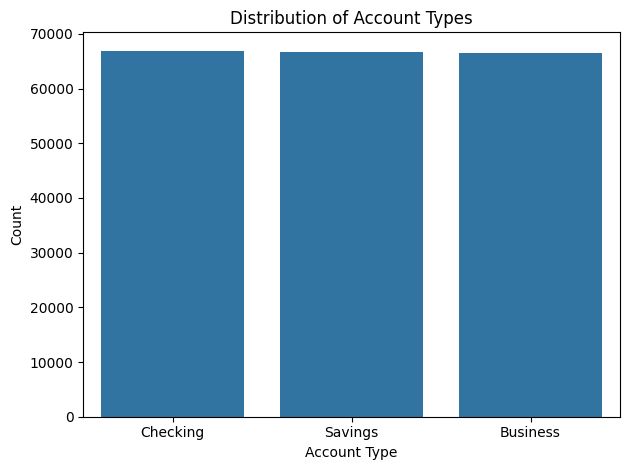

In [45]:
sns.countplot(data=df, x='Account_Type', order=df['Account_Type'].value_counts().index)

plt.title('Distribution of Account Types')
plt.xlabel('Account Type')
plt.ylabel('Count')

plt.tight_layout()

In [47]:
print(df['Transaction_ID'].nunique())
print(df['Transaction_Date'].nunique())

200000
31


In [48]:
# Create a completely separate copy in memory
df_explore = df.copy()
df_explore['Transaction_Date'] = pd.to_datetime(df_explore['Transaction_Date'], format='%d-%m-%Y')
df_explore['Day_of_Week'] = df_explore['Transaction_Date'].dt.day_name()
df_explore['Hour'] = pd.to_datetime(df_explore['Transaction_Time'], format='%H:%M:%S').dt.hour

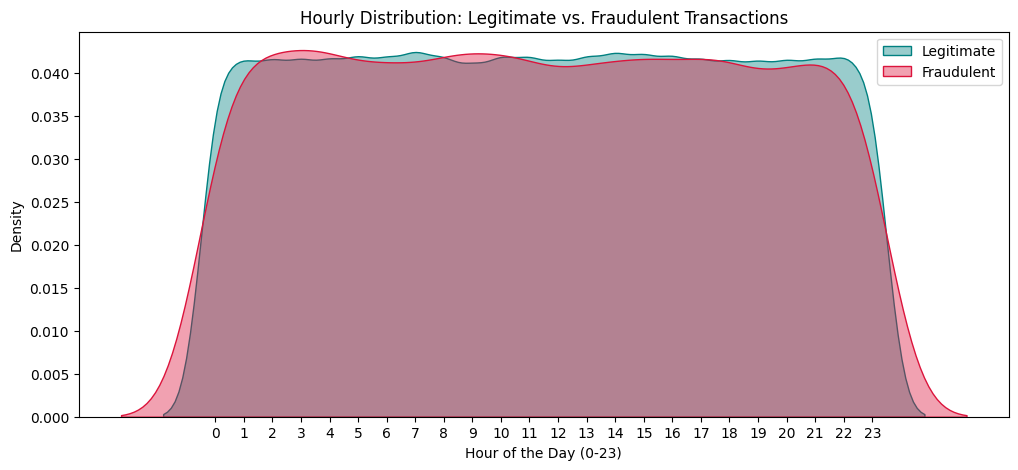

In [49]:
plt.figure(figsize=(12, 5))

# Plotting using the safe copy
sns.kdeplot(data=df_explore[df_explore['Is_Fraud'] == 0], x='Hour', label='Legitimate', fill=True, color='teal', alpha=0.4)
sns.kdeplot(data=df_explore[df_explore['Is_Fraud'] == 1], x='Hour', label='Fraudulent', fill=True, color='crimson', alpha=0.4)

plt.title('Hourly Distribution: Legitimate vs. Fraudulent Transactions')
plt.xlabel('Hour of the Day (0-23)')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

In [51]:
df['Merchant_ID'].nunique()

200000

In [56]:
df['Merchant_Category'].unique()

array(['Restaurant', 'Groceries', 'Entertainment', 'Health', 'Clothing',
       'Electronics'], dtype=object)

In [57]:
df['Merchant_Category'].value_counts()

,count
Merchant_Category,
Restaurant,33525
Entertainment,33421
Electronics,33409
Clothing,33340
Groceries,33187
Health,33118


In [59]:
df['Transaction_Device'].nunique()

20

In [60]:
print(df['Transaction_Device'].value_counts())

Transaction_Device
Self-service Banking Machine    21707
ATM                             21200
ATM Booth Kiosk                 21149
Debit/Credit Card                8273
Smart Card                       8133
Wearable Device                  8128
Virtual Card                     8059
Tablet                           8059
Desktop/Laptop                   8057
Voice Assistant                  8039
POS Mobile Device                8006
Banking Chatbot                  7995
Web Browser                      7981
Biometric Scanner                7952
QR Code Scanner                  7938
Mobile Device                    7879
Payment Gateway Device           7874
POS Mobile App                   7868
Bank Branch                      7855
POS Terminal                     7848
Name: count, dtype: int64


In [64]:
df['Device_Type'].unique()

array(['POS', 'Desktop', 'Mobile', 'ATM'], dtype=object)

In [65]:
df.groupby('Device_Type')['Transaction_Device'].unique()

,Transaction_Device
Device_Type,
ATM,"[Debit/Credit Card, Payment Gateway Device, AT..."
Desktop,"[POS Mobile Device, ATM, Payment Gateway Devic..."
Mobile,"[POS Mobile App, Virtual Card, ATM, Bank Branc..."
POS,"[Voice Assistant, Mobile Device, Desktop/Lapto..."


In [67]:
device_dict=dict(df.groupby('Device_Type')['Transaction_Device'].unique())
for i,j in device_dict.items():
  print(f"{i}")
  print(list(j))
  print()

ATM
['Debit/Credit Card', 'Payment Gateway Device', 'ATM', 'Voice Assistant', 'Smart Card', 'Biometric Scanner', 'Wearable Device', 'ATM Booth Kiosk', 'Virtual Card', 'POS Terminal', 'Bank Branch', 'Self-service Banking Machine', 'POS Mobile Device', 'QR Code Scanner', 'Banking Chatbot', 'Mobile Device', 'Desktop/Laptop', 'Tablet', 'POS Mobile App', 'Web Browser']

Desktop
['POS Mobile Device', 'ATM', 'Payment Gateway Device', 'Bank Branch', 'Desktop/Laptop', 'Biometric Scanner', 'Self-service Banking Machine', 'Tablet', 'POS Mobile App', 'ATM Booth Kiosk', 'Wearable Device', 'Smart Card', 'QR Code Scanner', 'POS Terminal', 'Banking Chatbot', 'Debit/Credit Card', 'Mobile Device', 'Web Browser', 'Voice Assistant', 'Virtual Card']

Mobile
['POS Mobile App', 'Virtual Card', 'ATM', 'Bank Branch', 'ATM Booth Kiosk', 'Self-service Banking Machine', 'QR Code Scanner', 'POS Terminal', 'Voice Assistant', 'Wearable Device', 'Banking Chatbot', 'Debit/Credit Card', 'Tablet', 'Payment Gateway Devic

# **Box Plot analysis**

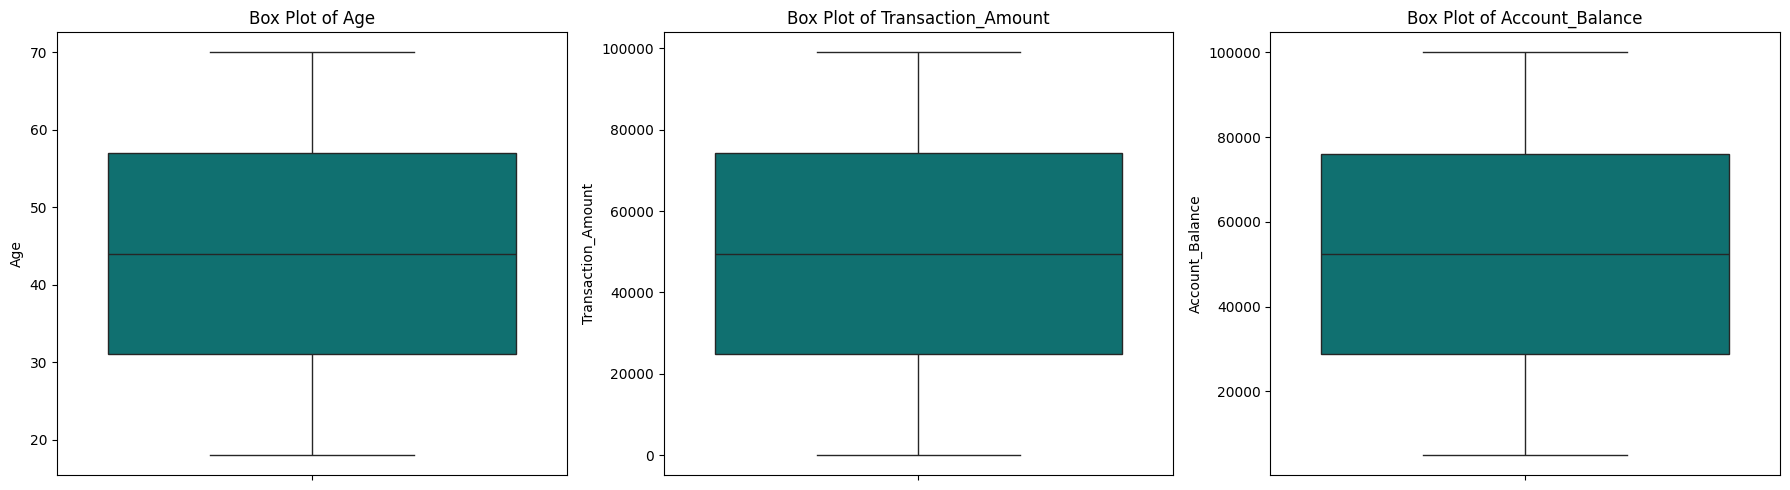

In [69]:
numeric_cols = ['Age', 'Transaction_Amount', 'Account_Balance']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='teal')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# **Correlation analysis**

In [73]:
cols_for_corr = ['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud']
numeric_corr = df[cols_for_corr].corr()
print(numeric_corr)

                         Age  Transaction_Amount  Account_Balance  Is_Fraud
Age                 1.000000           -0.003087         0.000269 -0.001517
Transaction_Amount -0.003087            1.000000        -0.001735 -0.002100
Account_Balance     0.000269           -0.001735         1.000000  0.000125
Is_Fraud           -0.001517           -0.002100         0.000125  1.000000


<Axes: >

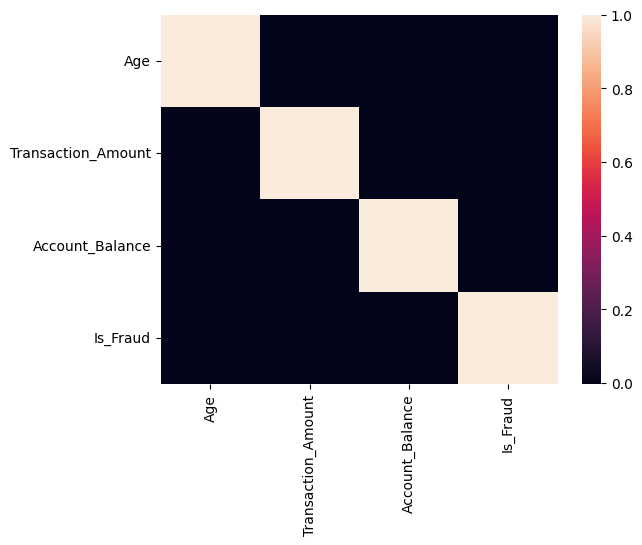

In [74]:
sns.heatmap(numeric_corr)

# **Initial Observation**

**Shape:** 200000 x 24

**Numerical columns:**['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud']


**Categorical columns:** ['Customer_ID', 'Customer_Name', 'Gender', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category',
       'Transaction_Device', 'Transaction_Location', 'Device_Type',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email']


**Target variable:** 'Is_Fraud'

It has significant imbalance 94.95 percent not fraud(0) cases and 5.04 percent fraud(1) cases


**Key observations:**
*  No missing values encountered
*  No duplicate values encountered
*  No outliers in the numerical columns


**Columns to be dropped**
*  'Customer_ID','Customer_Name','Merchant_ID','Customer_Email','Customer_Contact','Transaction_ID','Transaction_Description': These columns are unique identifiers or personal information and are unlikely to contribute to generalizable predictions.

*  'Transaction_Location','Bank_Branch': Not required since we already have coluns for City and State

*  'Transaction_Currency': Has a single value 'INR' . This will not help in prediction


**Some key obsrvations**
*  Gender is almost evenly distributed aong male and female
*  There are 34 unique values of state. This inlcudes 28 states and 6 union territories
*  Majorly 4-5 cities per state
*  Account_Type has 3 categories: Savings,Business,Checking
*  There are 6 types of merchant present: Restaurant,Groceries,Entertainment,Health,Clothing,Electronics
*  Device type has 4 types of devices which are further classified into Transaction device


**Feature engineering requirements**
*  Transactuion_Date should be converted to Day_Of_Week
*  Transaction_Time should be converted to Hour
*  Transaction_Amount and Account_Balance should be used to extract new features

**Observation from correlation analysis**
*  No strong linear correlations were observed among the numerical features. Linear models may rely more on engineered features, while tree-based models can capture non-linear relationships.
